In [12]:
import einops as eps
import torch
import torchvision.transforms as transforms
import numpy as np
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from dataset import FreiHand
from dataset.InterHand26M.utils.mano import mano

In [16]:
dataset = FreiHand(mode="test")
dataloader = torch.utils.data.DataLoader(dataset, batch_size=4)

In [17]:
from tqdm import tqdm

data_iter = iter(dataloader)
for _ in tqdm(range(233), ncols=50):
    data_item = next(data_iter)

100%|██████████| 233/233 [00:01<00:00, 222.95it/s]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


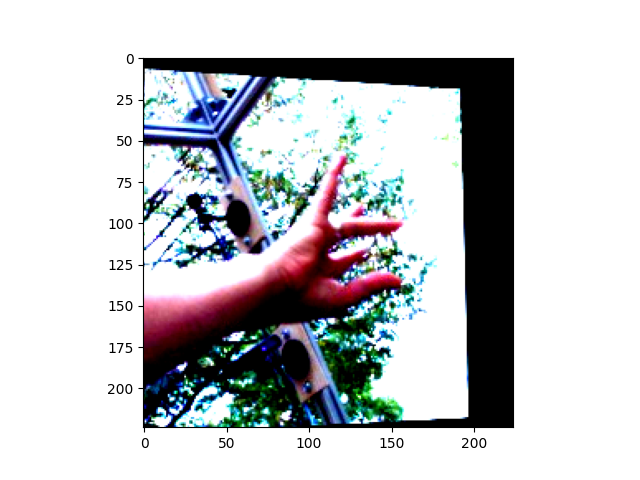

In [19]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

bx = 1

plt.clf()
image = data_item['image'][bx]
plt.imshow(image.permute(1,2,0))
plt.show()

In [37]:
data_item["uv_root"][bx]

tensor([111.2411, 113.4257])

In [33]:
pose = data_item['pose'][bx:bx+1]
shape = data_item['shape'][bx:bx+1]

output_gt = mano.layer['right'](betas=shape,
                             hand_pose=pose[:,3:],
                             global_orient=pose[:,:3],
                             transl=torch.zeros(1,3))

j1, j2 = output_gt.joints[0], data_item['joints_3d'][bx]

(tensor([[-3.2646e-02,  3.2643e-02,  4.8572e-01],
         [-2.2410e-04,  2.3005e-02,  5.6923e-01],
         [ 1.3797e-02,  1.6241e-02,  5.9812e-01],
         [ 3.0529e-02,  1.1343e-02,  6.1163e-01],
         [-4.0813e-04, -1.9385e-03,  5.6711e-01],
         [ 1.6623e-02, -1.2845e-02,  5.9133e-01],
         [ 3.0520e-02, -2.3302e-02,  6.0655e-01],
         [ 1.1595e-03, -2.8477e-02,  5.2721e-01],
         [ 8.7294e-03, -4.6385e-02,  5.3497e-01],
         [ 1.4822e-02, -6.3868e-02,  5.3812e-01],
         [-1.0771e-03, -1.8610e-02,  5.4640e-01],
         [ 2.6257e-02, -1.8216e-02,  5.5486e-01],
         [ 5.0858e-02, -1.8374e-02,  5.5497e-01],
         [-1.1601e-02,  5.0821e-02,  5.1206e-01],
         [ 1.8382e-02,  4.7763e-02,  5.1728e-01],
         [ 4.0897e-02,  3.8201e-02,  5.2857e-01]]),
 tensor([[-3.2646e-02,  3.2643e-02,  4.8572e-01],
         [-8.7316e-03,  4.2861e-02,  5.0770e-01],
         [ 1.3461e-02,  4.3601e-02,  5.1931e-01],
         [ 3.5773e-02,  3.4531e-02,  5.2168e-01]

In [10]:
import torch
import resnet

model: torch.nn.Module = resnet.pose_resnet50()
ckpt = torch.load("logs/23-20240927-1/checkpoint-299.pth", map_location="cpu", weights_only=False)
# logs/22-20240919-1/checkpoint-29.pth
model.load_state_dict(ckpt["model"])
model.to("cuda:5")
model.eval()
pass

trigger EVAL mode


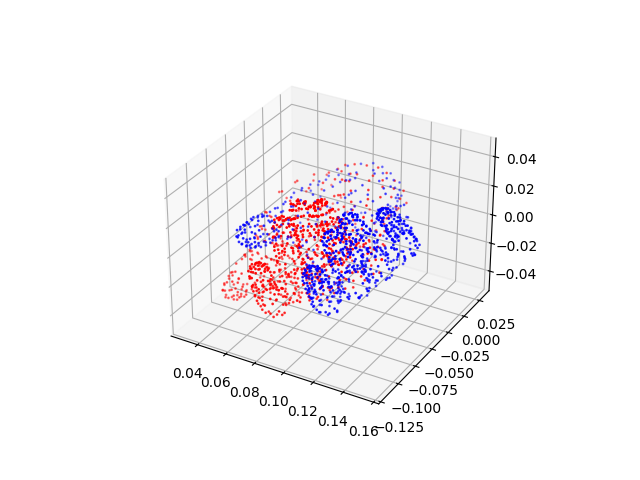

In [11]:
%matplotlib widget

with torch.no_grad():
    pose_pred = model(data_item["image"].to("cuda:5"))
    pose_pred = pose_pred[bx:bx+1].reshape(1,-1).to("cpu").detach()

pose = data_item['pose'][bx:bx+1]
shape = data_item['shape'][bx:bx+1]

output_gt = mano.layer['right'](betas=shape,
                             hand_pose=pose[:,3:],
                             global_orient=pose[:,:3],
                             transl=torch.zeros(1,3))
output_pred = mano.layer["right"](betas=shape,
                                  hand_pose=pose_pred[:,3:],
                                  global_orient=pose_pred[:,:3],
                                  transl=torch.zeros(1,3))

mesh_gt = output_gt.vertices[0]
mesh_pred = output_pred.vertices[0]

plt.clf()
fig3d = plt.figure(3)
ax3d = fig3d.add_subplot(111, projection='3d')
ax3d.scatter(mesh_gt[:,0],mesh_gt[:,1],mesh_gt[:,2], s=1, c='r')
ax3d.scatter(mesh_pred[:,0],mesh_pred[:,1],mesh_pred[:,2], s=1, c='b')

plt.show()